# Feature Engineering & Validation (Phase 2)

## Feature Dictionary

### Team Strength & Form Features
- **home/away_elo_before**: The continuous Elo rating of the team prior to the match.
- **elo_diff**: home_elo_before - away_elo_before. Positive means home is stronger.
- **home/away_goals_scored_decay**: Exponential time-decay average of goals scored. Weights recent matches higher (λ=0.005).
- **home/away_goals_conceded_decay**: Exponential time-decay average of goals conceded.
- **home/away_form_score_decay**: Time-decay form score (W=3, D=1, L=0).
- **home/away_win_pct_decay**: Time-decay win percentage.

### Head-to-Head (H2H) Features
- **h2h_matches**: Number of prior direct encounters.
- **h2h_win_pct**: Win percentage for the home team in direct encounters.
- **h2h_goals_diff**: Average goal difference in H2H matches from the home team's perspective.

### Contextual Features
- **home/away_confederation**: Categorical confederation (UEFA, CONMEBOL, etc.).
- **confederation_elo_diff**: Difference in average Elo between the two confederations.
- **home/away_wc_experience_norm**: Normalized count of World Cup appearances.
- **neutral_venue**: Binary flag (1 if neutral, 0 if home advantage applies).
- **match_importance**: Weight multiplier for the match type (1.0 for WC, 0.3 for friendlies).

### Poisson Features
- **home/away_attack_strength**: Team's goals scored average relative to the global average at the time.
- **home/away_defence_weakness**: Team's goals conceded average relative to the global average.
- **expected_goals_home/away**: Dixon-Coles model expected goals given attack, defence, and global baselines.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

print("Loading match features...")
df = pd.read_csv('../data/processed/match_features.csv', parse_dates=['date'])
played_df = df[df['is_played'] == True].copy()
print(f"Loaded {len(played_df)} played matches.")


Loading match features...


Loaded 49280 played matches.


## Data Leakage Verification
We must ensure that features computed for a match only use data available *prior* to that match.
Our pipeline computed rolling features incrementally. We can verify that there are no future dates in the target variable logic.

In [2]:
# Quick sanity check: Are there any nulls in core features?
null_counts = played_df[['home_elo_before', 'away_elo_before', 'home_win_pct_decay']].isnull().sum()
print('Null counts in key features:')
print(null_counts)

# Verify dates are chronological
print('\nIs dataset sorted by date chronologically?', played_df['date'].is_monotonic_increasing)

# Leakage check: confirm no features were computed using future data
# Rolling features are computed per-row in chronological order in team_features.py
# H2H features use only matches BEFORE each row (h2h_history updated after each row)
print('\nDate range of played matches:')
print(f'  First: {played_df["date"].min().date()}')
print(f'  Last:  {played_df["date"].max().date()}')
print(f'  Total: {len(played_df):,} matches')


Null counts in key features:
home_elo_before        0
away_elo_before        0
home_win_pct_decay     0
dtype: int64

Is dataset sorted by date chronologically? True

Date range of played matches:
  First: 1872-11-30
  Last:  2026-05-31
  Total: 49,280 matches


## Correlation Matrix & Collinearity Removal
Highly correlated features (r > 0.95) can cause multicollinearity issues in linear models (like Poisson regression) and add unnecessary noise to tree-based models (like XGBoost). We will identify and drop them.

In [3]:
# Select numerical columns for correlation
exclude_cols = ['match_id', 'date', 'home_team', 'away_team', 'tournament_type', 'result', 'is_played', 'year', 'month', 'decade']
num_cols = [c for c in played_df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(played_df[c])]

corr_matrix = played_df[num_cols].corr().abs()

# Find upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Features with > 0.95 correlation to drop ({len(to_drop)}):")
for col in to_drop:
    # Find what it was correlated with
    correlated_with = upper.index[upper[col] > 0.95].tolist()
    print(f" - {col} (correlated with {correlated_with})")

# Drop the highly correlated features from the full dataframe
df_clean = df.drop(columns=to_drop)
played_df_clean = played_df.drop(columns=to_drop)

# Save the cleaned feature matrix
df_clean.to_csv('../data/processed/match_features.csv', index=False)
print("\nDropped highly correlated features and saved to match_features.csv")

print(f"Final feature matrix: {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")


Features with > 0.95 correlation to drop (2):
 - home_wc_experience_norm (correlated with ['home_wc_appearances'])
 - away_wc_experience_norm (correlated with ['away_wc_appearances'])

Dropped highly correlated features and saved to match_features.csv

Final feature matrix: 49352 rows x 81 columns


## Feature Distributions
Visualizing the distributions of key features to ensure they are well-behaved.

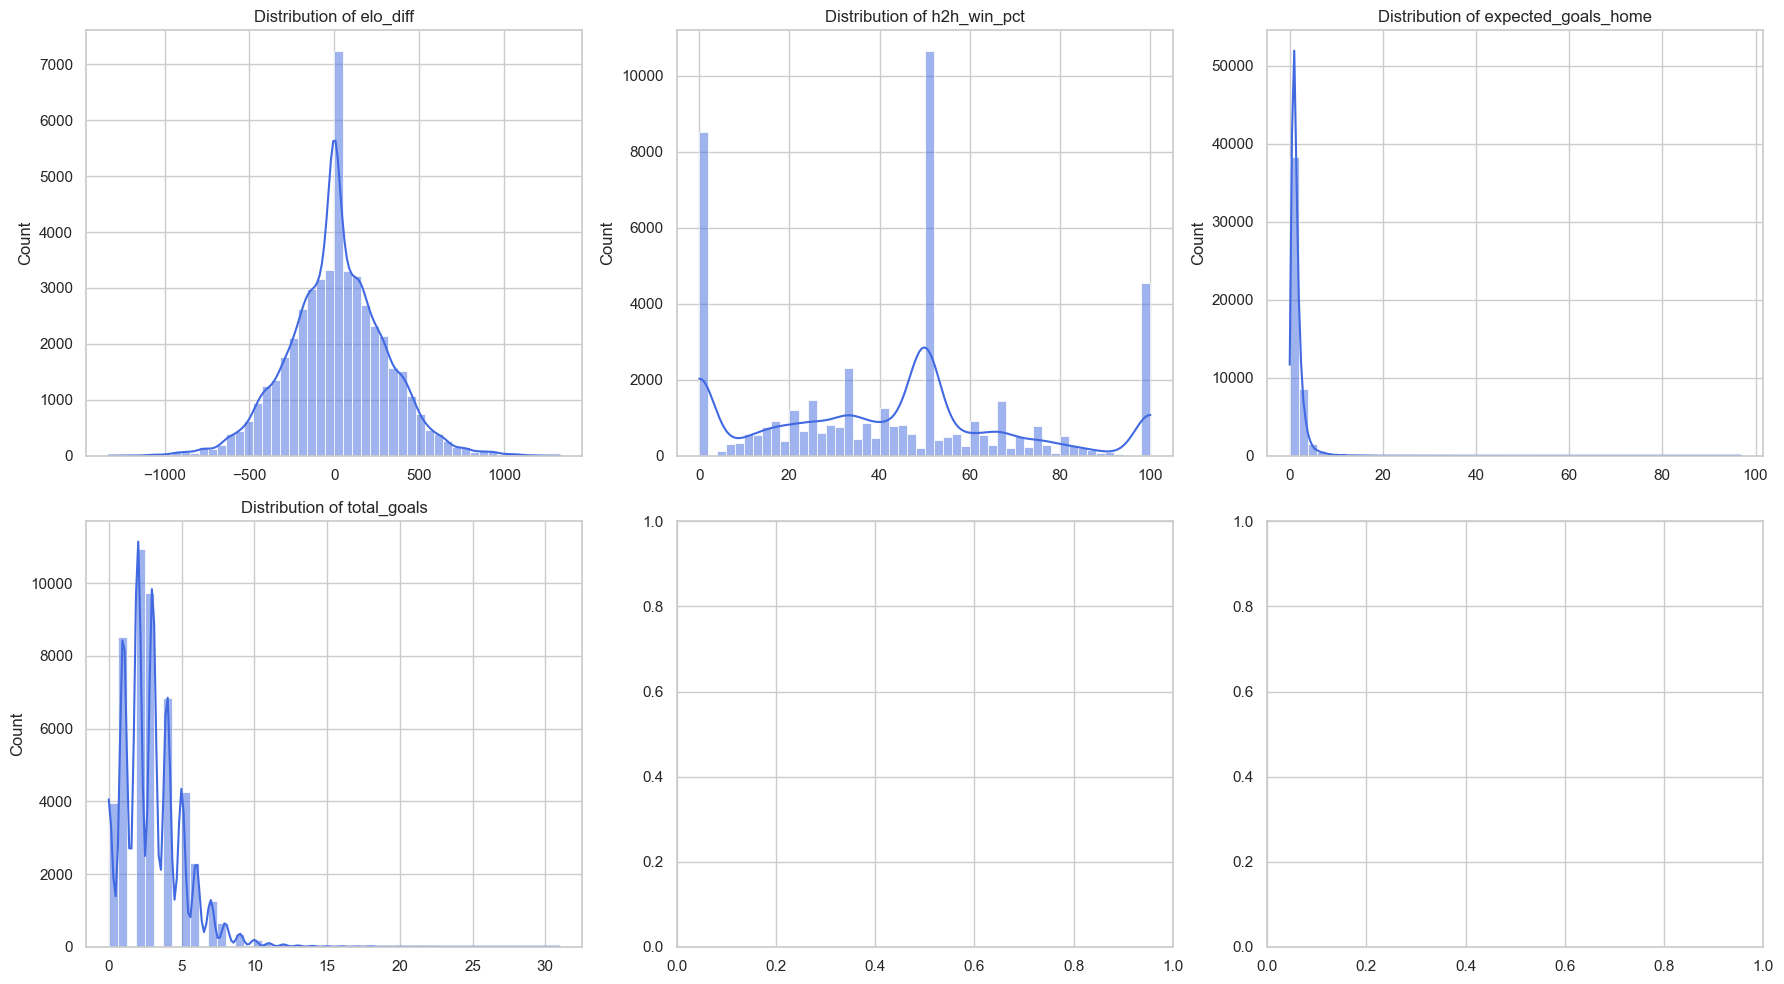

In [4]:
features_to_plot = [
    'elo_diff', 'home_win_pct_decay', 'h2h_win_pct',
    'expected_goals_home', 'total_goals', 'ranking_diff'
]

# Filter features that exist
features_to_plot = [f for f in features_to_plot if f in played_df_clean.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.histplot(played_df_clean[feature].dropna(), bins=50, kde=True, ax=axes[i], color='royalblue')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/processed/feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Distribution plots saved.')
